# MS_00b — Cross-Station Comparative EDA

Exploratory analysis across **all Warsaw PM2.5 monitoring stations** in a single view.
Unlike `MS_00_EDA.ipynb` (which loops per-station), this notebook produces combined
multi-station figures: missingness, distributions, temporal patterns, inter-station
correlations, and a spatial map.

All figures are displayed inline only (no per-station file saves).

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATA_PATH, ALL_STATIONS, MET_COLS,
    WHO_24H_PM25, STATION_COORDS,
)
from src.data_loader import load_data

sns.set_theme(style='whitegrid', palette='tab10')
PALETTE = dict(zip(ALL_STATIONS, sns.color_palette('tab10', len(ALL_STATIONS))))

df_full = load_data(DATA_PATH)

STATIONS = [s for s in ALL_STATIONS if s in df_full.columns]
station_df = df_full[STATIONS].copy()

# Short display labels
LABELS = {s: s[-8:] for s in STATIONS}
label_order = [LABELS[s] for s in STATIONS]

print(f'Loaded: {df_full.shape}  |  {df_full.index.min()} → {df_full.index.max()}')
print(f'Stations: {STATIONS}')

06:49:40 | src.data_loader | INFO | Loading data from D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\data\raw\FINAL_merged_PM25_1g_all_seasons.csv
06:49:40 | src.data_loader | INFO | Missing values per column:
MzOtwoBrzozo    1084
MzWarWokalna    2028
MzWarAlNiepo     575
MzLegZegrzyn    1511
MzPiasPulask    1002
MzWarChrosci     416
MzWarBajkowa     636
dir_48            48
dir_24            48
06:49:40 | src.data_loader | INFO | Loaded 52608 rows, 27 columns, range 2019-01-01 00:00:00 → 2024-12-31 23:00:00


Loaded: (52608, 27)  |  2019-01-01 00:00:00 → 2024-12-31 23:00:00
Stations: ['MzWarChrosci', 'MzOtwoBrzozo', 'MzWarWokalna', 'MzWarAlNiepo', 'MzLegZegrzyn', 'MzPiasPulask', 'MzWarBajkowa']


## 1. Missing Data — All Stations

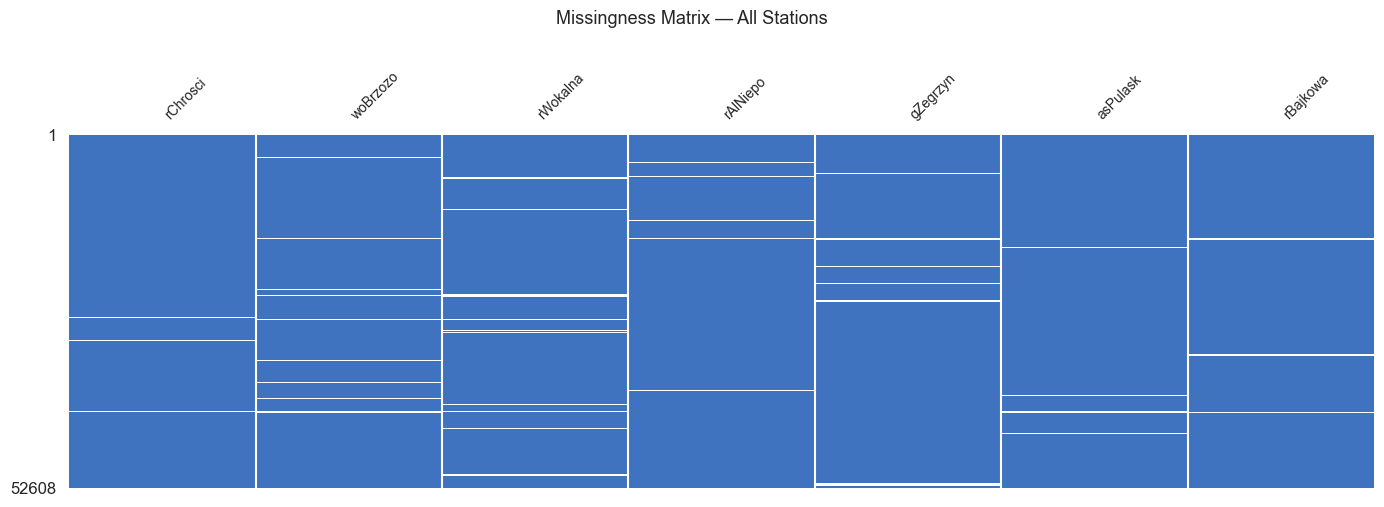

,Missing N,Missing %
rChrosci,416,0.79
woBrzozo,1084,2.06
rWokalna,2028,3.85
rAlNiepo,575,1.09
gZegrzyn,1511,2.87
asPulask,1002,1.90
rBajkowa,636,1.21


In [2]:
import missingno as msno

msno.matrix(station_df.rename(columns=LABELS), figsize=(14, 5),
            sparkline=False, color=(0.25, 0.45, 0.75), fontsize=10)
plt.suptitle('Missingness Matrix — All Stations', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

miss = station_df.isnull().mean().mul(100).round(2).rename('Missing %')
total = station_df.isnull().sum().rename('Missing N')
summary = pd.concat([total, miss], axis=1)
summary.index = [LABELS[s] for s in summary.index]
display(summary)

## 2. PM2.5 Distribution — All Stations

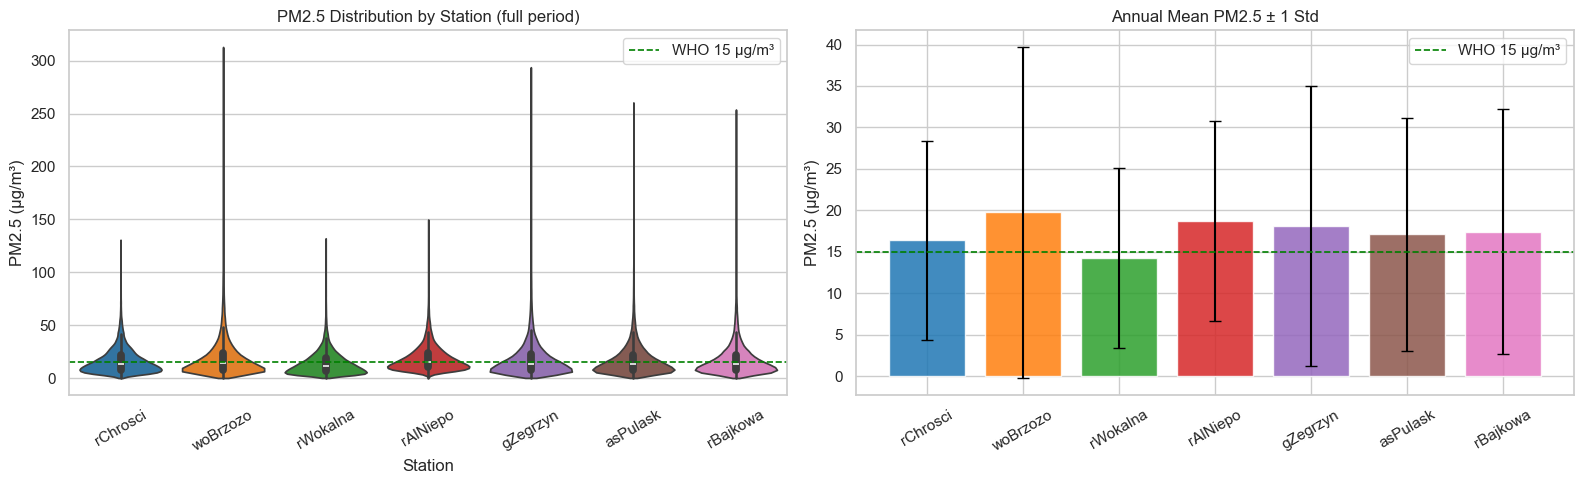

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_data = station_df.melt(var_name='Station', value_name='PM25').dropna()
plot_data['Station'] = plot_data['Station'].map(LABELS)

sns.violinplot(data=plot_data, x='Station', y='PM25', order=label_order,
               palette='tab10', inner='box', cut=0, ax=axes[0])
axes[0].axhline(WHO_24H_PM25, color='green', linestyle='--', linewidth=1.2,
                label=f'WHO {WHO_24H_PM25} μg/m³')
axes[0].set_title('PM2.5 Distribution by Station (full period)')
axes[0].set_xlabel('Station')
axes[0].set_ylabel('PM2.5 (μg/m³)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

annual_mean = station_df.mean()
annual_std  = station_df.std()
colors = [PALETTE[s] for s in STATIONS]
axes[1].bar([LABELS[s] for s in STATIONS], annual_mean[STATIONS],
            yerr=annual_std[STATIONS], capsize=4,
            color=colors, edgecolor='white', alpha=0.85)
axes[1].axhline(WHO_24H_PM25, color='green', linestyle='--', linewidth=1.2,
                label=f'WHO {WHO_24H_PM25} μg/m³')
axes[1].set_title('Annual Mean PM2.5 ± 1 Std')
axes[1].set_ylabel('PM2.5 (μg/m³)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

## 3. Seasonal Distribution by Station

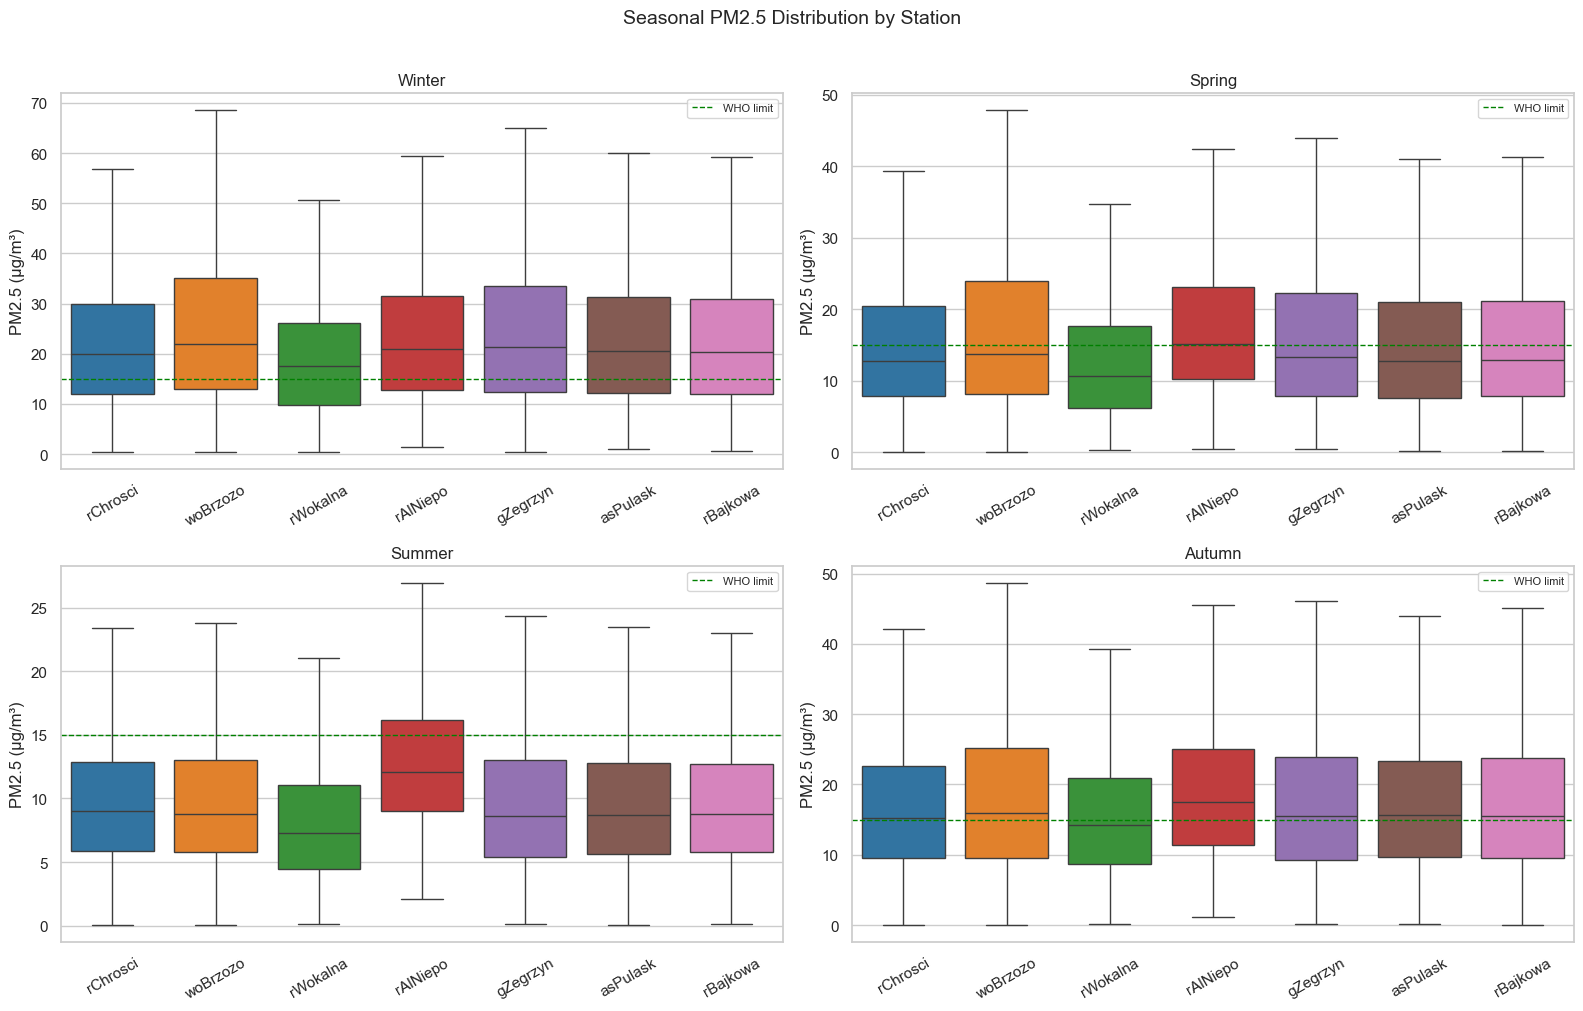

In [4]:
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

melted = station_df.copy()
melted['Season'] = melted.index.month.map(season_map)
melted = melted.melt(id_vars='Season', var_name='Station', value_name='PM25').dropna()
melted['Station'] = melted['Station'].map(LABELS)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, season in zip(axes.flat, season_order):
    sub = melted[melted['Season'] == season]
    sns.boxplot(data=sub, x='Station', y='PM25', order=label_order,
                palette='tab10', showfliers=False, ax=ax)
    ax.axhline(WHO_24H_PM25, color='green', linestyle='--', linewidth=1, label='WHO limit')
    ax.set_title(season)
    ax.set_ylabel('PM2.5 (μg/m³)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

fig.suptitle('Seasonal PM2.5 Distribution by Station', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 4. Temporal Patterns — All Stations Combined

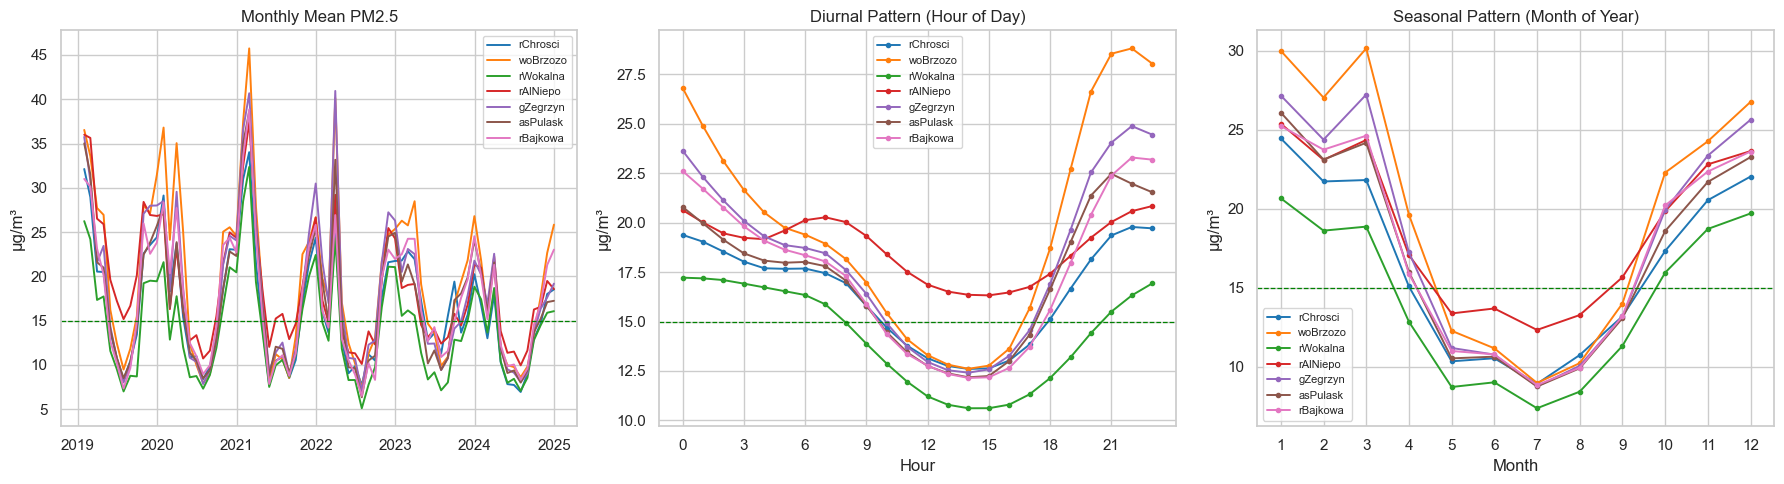

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for station in STATIONS:
    col = station_df[station]
    label = LABELS[station]
    color = PALETTE[station]

    monthly = col.resample('ME').mean()
    axes[0].plot(monthly.index, monthly.values, label=label, color=color, linewidth=1.4)

    hourly = col.groupby(col.index.hour).mean()
    axes[1].plot(hourly.index, hourly.values, label=label, color=color,
                 linewidth=1.4, marker='o', markersize=3)

    by_month = col.groupby(col.index.month).mean()
    axes[2].plot(by_month.index, by_month.values, label=label, color=color,
                 linewidth=1.4, marker='o', markersize=3)

for ax, title, xlabel in [
    (axes[0], 'Monthly Mean PM2.5', ''),
    (axes[1], 'Diurnal Pattern (Hour of Day)', 'Hour'),
    (axes[2], 'Seasonal Pattern (Month of Year)', 'Month'),
]:
    ax.axhline(WHO_24H_PM25, color='green', linestyle='--', linewidth=0.9)
    ax.set_title(title)
    ax.set_ylabel('μg/m³')
    if xlabel:
        ax.set_xlabel(xlabel)
    ax.legend(fontsize=8)

axes[1].set_xticks(range(0, 24, 3))
axes[2].set_xticks(range(1, 13))

fig.tight_layout()
plt.show()

## 5. Inter-Station PM2.5 Correlation

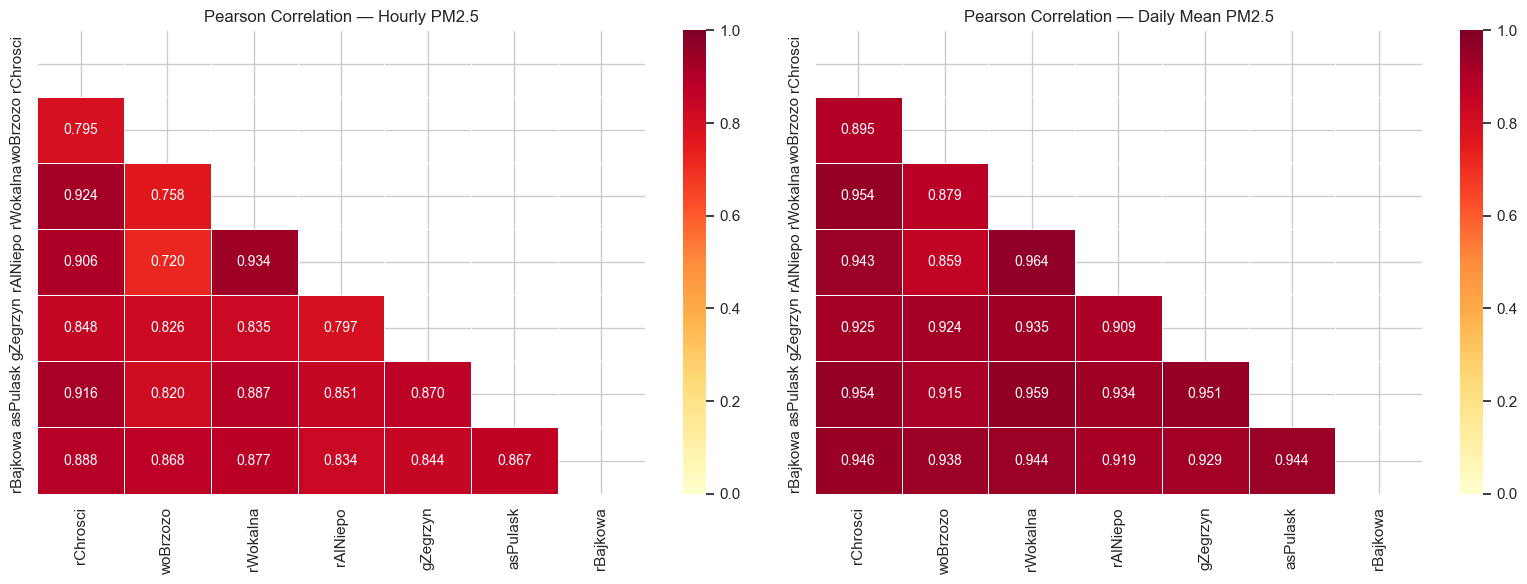

In [6]:
corr_hourly = station_df.rename(columns=LABELS).corr()
corr_daily  = station_df.resample('D').mean().rename(columns=LABELS).corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask = np.triu(np.ones_like(corr_hourly, dtype=bool))
sns.heatmap(corr_hourly, mask=mask, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=axes[0], linewidths=0.5, annot_kws={'size': 10})
axes[0].set_title('Pearson Correlation — Hourly PM2.5')

mask2 = np.triu(np.ones_like(corr_daily, dtype=bool))
sns.heatmap(corr_daily, mask=mask2, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=axes[1], linewidths=0.5, annot_kws={'size': 10})
axes[1].set_title('Pearson Correlation — Daily Mean PM2.5')

fig.tight_layout()
plt.show()

## 6. Spatial Map — Mean PM2.5 per Station

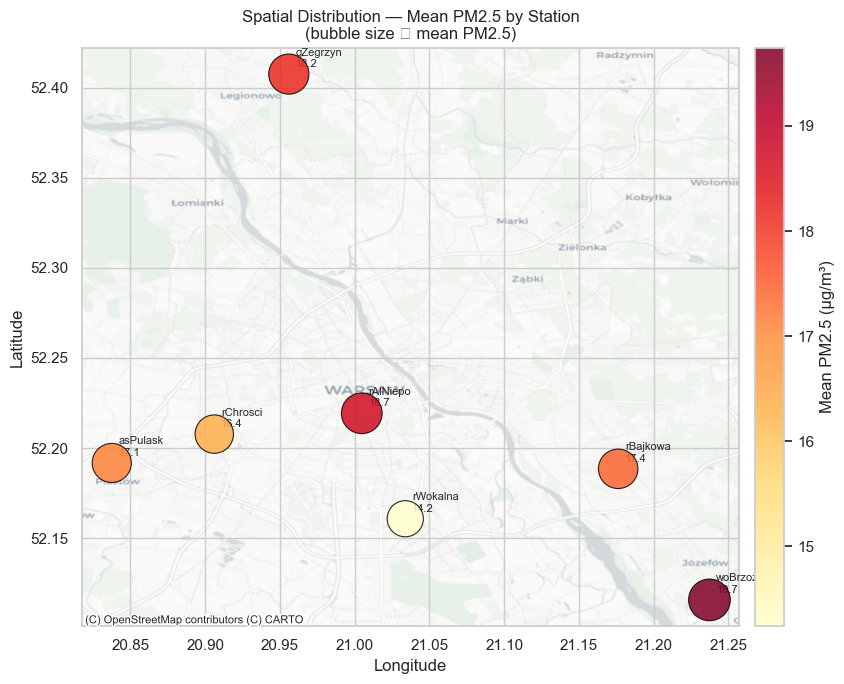

In [7]:
try:
    import contextily as ctx
    HAS_CTX = True
except ImportError:
    HAS_CTX = False

mean_pm25 = station_df.mean()
lats   = [STATION_COORDS[s][0] for s in STATIONS]
lons   = [STATION_COORDS[s][1] for s in STATIONS]
means  = [mean_pm25[s] for s in STATIONS]

fig, ax = plt.subplots(figsize=(9, 7))
sizes = [(v / max(means)) * 800 + 100 for v in means]
scatter = ax.scatter(lons, lats, s=sizes, c=means, cmap='YlOrRd',
                     alpha=0.85, edgecolors='black', linewidths=0.8, zorder=5)
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Mean PM2.5 (μg/m³)')

for lon, lat, s, val in zip(lons, lats, STATIONS, means):
    ax.annotate(f'{LABELS[s]}\n{val:.1f}', xy=(lon, lat),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Distribution — Mean PM2.5 by Station\n(bubble size ∝ mean PM2.5)')

if HAS_CTX:
    ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, zoom=11)

fig.tight_layout()
plt.show()

## 7. Summary Statistics

In [8]:
rows = []
for s in STATIONS:
    col = station_df[s].dropna()
    rows.append({
        'Station': LABELS[s],
        'N': len(col),
        'Missing %': round(station_df[s].isnull().mean() * 100, 2),
        'Mean': round(col.mean(), 2),
        'Std': round(col.std(), 2),
        'Min': round(col.min(), 2),
        'Q25': round(col.quantile(0.25), 2),
        'Median': round(col.median(), 2),
        'Q75': round(col.quantile(0.75), 2),
        'Max': round(col.max(), 2),
        'WHO>15 %': round((col > WHO_24H_PM25).mean() * 100, 2),
    })

summary_stats = pd.DataFrame(rows).set_index('Station')
display(summary_stats)

,N,Missing %,Mean,Std,Min,Q25,Median,Q75,Max,WHO>15 %
Station,,,,,,,,,,
rChrosci,52192,0.79,16.39,12.00,0.00,7.96,13.22,21.47,130.66,43.07
woBrzozo,51524,2.06,19.74,19.96,0.04,8.00,13.90,24.10,312.92,46.21
rWokalna,50580,3.85,14.24,10.86,0.09,6.40,11.50,19.07,132.06,36.45
rAlNiepo,52033,1.09,18.73,12.06,0.41,10.40,15.50,23.64,149.80,52.10
gZegrzyn,51097,2.87,18.16,16.88,0.11,7.67,13.54,22.90,293.79,44.72
asPulask,51606,1.90,17.12,14.04,0.08,7.80,13.30,22.04,260.49,43.61
rBajkowa,51972,1.21,17.44,14.77,0.00,7.95,13.23,22.10,253.78,43.35
